# Bài thực hành số 2 — Markov Decision Process và Dynamic Programming

**Học phần:** Học tăng cường — Reinforcement Learning

| | |
|---|---|
| Họ tên | Nguyen Quang Trung |
| MSSV | 22011211 |
| Lớp | K16_AI&RB |
| GitHub username | Qwup2112 |
| Repository | <https://github.com/Qwup2112/RL_22011211_NGUYEN_QUANG_TRUNG> |

Notebook này chạy lại 36 bài trong `Lab02/src/` và ghi nhận kết quả, biểu đồ,
nhận xét. Mọi thuật toán Dynamic Programming được **tự cài đặt** trong
`src/mdp_utils.py`; không dùng thư viện RL nào có sẵn `value_iteration()` hay
`policy_iteration()`, và không hard-code optimal policy.

In [1]:
# Cho phep notebook import cac module trong Lab02/src/
import sys
from pathlib import Path

SRC_DIR = (Path.cwd().parent / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("src dir:", SRC_DIR, "| exists:", SRC_DIR.exists())

src dir: D:\new_code\Lab02\src | exists: True


In [2]:
# Import truoc cac module co dat backend "Agg" (de chay duoc tu terminal),
# sau do moi bat lai che do inline cho notebook o cac cell ve bieu do.
import gymnasium as gym
import numpy as np

import bai04, bai06, bai10, bai25, bai29, bai32, bai35, bai36
import mdp_utils as U

print("Gymnasium:", gym.__version__, "| NumPy:", np.__version__)

Gymnasium: 1.3.0 | NumPy: 2.5.2


---
## PHẦN A — Markov Chain (Bài 1–6)

### Bài 1–3. Transition matrix, kiểm tra tính hợp lệ, một bước chuyển

In [3]:
from bai01 import P, STATE_NAMES, print_transition_matrix
from bai02 import validate_transition_matrix
from bai03 import next_distribution

print_transition_matrix(P, STATE_NAMES)
print()
print("Row sums:", P.sum(axis=1))
print("Hop le  :", validate_transition_matrix(P))
print()

p0 = np.array([1.0, 0.0, 0.0])   # hom nay chac chan Sunny
p1 = next_distribution(p0, P)
print("p0 =", p0)
print("p1 = p0 @ P =", np.round(p1, 6))

from -> to  |  Sunny  | Cloudy  |  Rainy 
-----------------------------------------
Sunny      |  0.80   |  0.15   |  0.05  
Cloudy     |  0.30   |  0.40   |  0.30  
Rainy      |  0.20   |  0.30   |  0.50  

Row sums: [1. 1. 1.]
Hop le  : True

p0 = [1. 0. 0.]
p1 = p0 @ P = [0.8  0.15 0.05]


### Bài 4. Phân phối sau nhiều bước — hội tụ về stationary distribution

  t  |  Sunny   |  Cloudy  |  Rainy  
-------------------------------------
  0  | 1.000000 | 0.000000 | 0.000000
  1  | 0.800000 | 0.150000 | 0.050000
  2  | 0.695000 | 0.195000 | 0.110000
  5  | 0.584660 | 0.232091 | 0.183249
 10  | 0.561457 | 0.239533 | 0.199010
 50  | 0.560000 | 0.240000 | 0.200000

Stationary distribution: [0.56 0.24 0.2 ]
Bat dau tu Rainy       : [0.56 0.24 0.2 ]


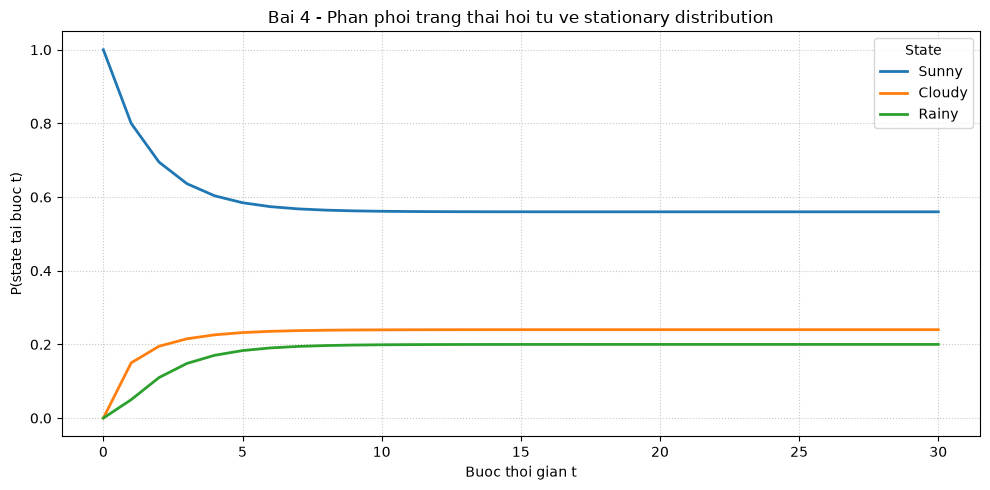

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

from bai04 import state_distribution

header = "  t  | " + " | ".join(f"{name:^8s}" for name in STATE_NAMES)
print(header)
print("-" * len(header))
for n_steps in [0, 1, 2, 5, 10, 50]:
    distribution = state_distribution(p0, P, n_steps)
    print(f"{n_steps:^5d}| " + " | ".join(f"{v:^8.6f}" for v in distribution))

stationary = state_distribution(p0, P, 200)
print()
print("Stationary distribution:", np.round(stationary, 6))
print("Bat dau tu Rainy       :",
      np.round(state_distribution(np.array([0.0, 0.0, 1.0]), P, 200), 6))

history = np.array([state_distribution(p0, P, t) for t in range(31)])
figure, axes = plt.subplots(figsize=(10, 5))
for index, name in enumerate(STATE_NAMES):
    axes.plot(range(31), history[:, index], linewidth=2.0, label=name)
axes.set_title("Bai 4 - Phan phoi trang thai hoi tu ve stationary distribution")
axes.set_xlabel("Buoc thoi gian t")
axes.set_ylabel("P(state tai buoc t)")
axes.grid(True, linestyle=":", alpha=0.7)
axes.legend(title="State")
figure.tight_layout()
plt.show()

### Bài 5–6. Mô phỏng và so sánh với lý thuyết

In [5]:
from bai05 import simulate_chain
from bai06 import simulate_frequencies

rng = np.random.default_rng(42)
states = simulate_chain(0, P, 30, rng)
print("Chuoi 30 transition:")
print(" -> ".join(STATE_NAMES[state] for state in states))
print()

empirical = simulate_frequencies(P, 100_000)
print("State   | Ly thuyet | Mo phong  | Sai lech")
print("--------+-----------+-----------+---------")
for index, name in enumerate(STATE_NAMES):
    print(f"{name:<8s}| {stationary[index]:^10.6f}| {empirical[index]:^10.6f}| "
          f"{empirical[index] - stationary[index]:+.6f}")
print()
print(f"Sai lech lon nhat: {float(np.max(np.abs(empirical - stationary))):.6f}")

Chuoi 30 transition:
Sunny -> Sunny -> Sunny -> Cloudy -> Cloudy -> Sunny -> Rainy -> Rainy -> Rainy -> Sunny -> Sunny -> Sunny -> Cloudy -> Cloudy -> Rainy -> Cloudy -> Sunny -> Sunny -> Sunny -> Cloudy -> Cloudy -> Rainy -> Cloudy -> Rainy -> Rainy -> Rainy -> Sunny -> Sunny -> Sunny -> Sunny -> Sunny



State   | Ly thuyet | Mo phong  | Sai lech
--------+-----------+-----------+---------
Sunny   |  0.560000 |  0.559830 | -0.000170
Cloudy  |  0.240000 |  0.237950 | -0.002050
Rainy   |  0.200000 |  0.202220 | +0.002220

Sai lech lon nhat: 0.002220


**Nhận xét (Bài 6).** Tần suất mô phỏng khớp với stationary distribution tính
bằng phép nhân ma trận tới 3 chữ số thập phân. Đó là hệ quả của luật số lớn:
sai số giảm theo `1/sqrt(n)`. Trạng thái xuất phát không còn ảnh hưởng sau vài
chục bước vì chuỗi Markov này ergodic — mọi phân phối ban đầu đều hội tụ về
cùng một kết quả. Đây cũng là lý do có thể đánh giá một policy bằng mô phỏng
(Bài 34) thay vì phải tính giải tích.

---
## PHẦN B — Reward, Return và Discount Factor (Bài 7–11)

```text
G_t = R_(t+1) + gamma*R_(t+2) + gamma^2*R_(t+3) + ...
```

In [6]:
from bai07 import compute_return
from bai09 import discounted_returns

rewards = [1, 1, 1, 1, 1]
print("rewards =", rewards)
print()
print("| Gamma | Return |")
print("|------:|-------:|")
for gamma in [0.0, 0.5, 0.9, 0.99, 1.0]:
    print(f"| {gamma:5.2f} | {compute_return(rewards, gamma):6.4f} |")

print()
print("Bai 9 - return tinh nguoc tu cuoi episode, rewards = [0, 0, 0, 1]:")
for gamma in [1.0, 0.9]:
    values = discounted_returns([0, 0, 0, 1], gamma)
    print(f"  gamma={gamma}: " + ", ".join(f"G_{i}={v:.4f}" for i, v in enumerate(values)))

rewards = [1, 1, 1, 1, 1]

| Gamma | Return |
|------:|-------:|
|  0.00 | 1.0000 |
|  0.50 | 1.9375 |
|  0.90 | 4.0951 |
|  0.99 | 4.9010 |
|  1.00 | 5.0000 |

Bai 9 - return tinh nguoc tu cuoi episode, rewards = [0, 0, 0, 1]:
  gamma=1.0: G_0=1.0000, G_1=1.0000, G_2=1.0000, G_3=1.0000
  gamma=0.9: G_0=0.7290, G_1=0.8100, G_2=0.9000, G_3=1.0000


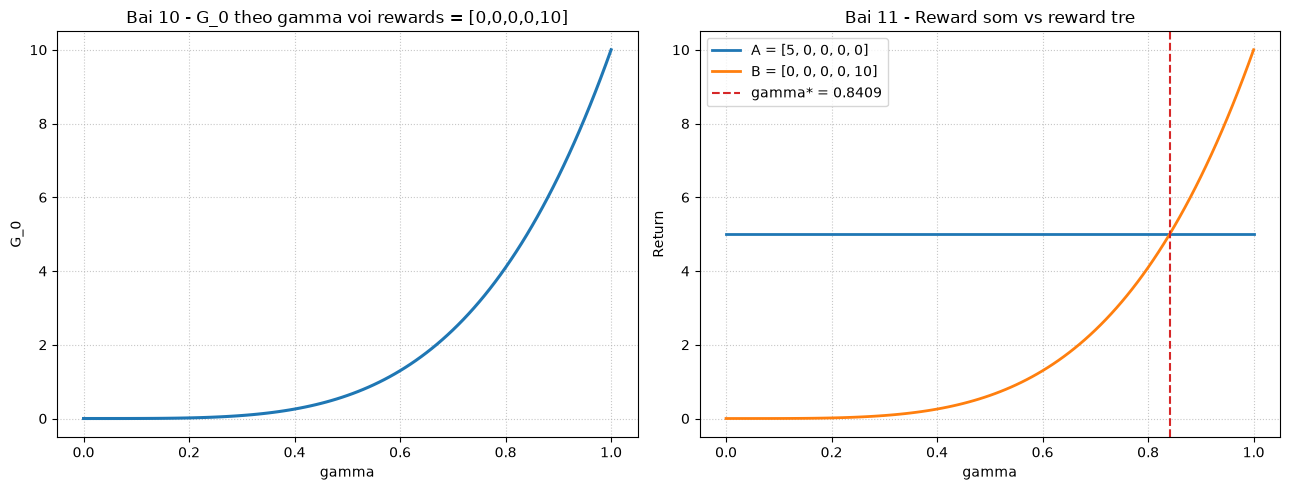

B co return lon hon A khi gamma > 0.840896  (nghiem giai tich 0.5^(1/4) = 0.840896)


In [7]:
%matplotlib inline
from bai11 import find_crossover_gamma, sequence_A, sequence_B

late_rewards = [0, 0, 0, 0, 10]
gammas = np.linspace(0, 1, 101)
returns = [compute_return(late_rewards, g) for g in gammas]

returns_A = [compute_return(sequence_A, g) for g in gammas]
returns_B = [compute_return(sequence_B, g) for g in gammas]
crossover = find_crossover_gamma(sequence_A, sequence_B)

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(gammas, returns, linewidth=2.2, color="#1f77b4")
axes[0].set_title("Bai 10 - G_0 theo gamma voi rewards = [0,0,0,0,10]")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("G_0")
axes[0].grid(True, linestyle=":", alpha=0.7)

axes[1].plot(gammas, returns_A, linewidth=2.0, label=f"A = {sequence_A}")
axes[1].plot(gammas, returns_B, linewidth=2.0, label=f"B = {sequence_B}")
axes[1].axvline(crossover, color="#d62728", linestyle="--",
                label=f"gamma* = {crossover:.4f}")
axes[1].set_title("Bai 11 - Reward som vs reward tre")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("Return")
axes[1].grid(True, linestyle=":", alpha=0.7)
axes[1].legend()

figure.tight_layout()
plt.show()

print(f"B co return lon hon A khi gamma > {crossover:.6f}  "
      f"(nghiem giai tich 0.5^(1/4) = {0.5 ** 0.25:.6f})")

**Nhận xét.** `gamma` quyết định agent "kiên nhẫn" đến đâu. Với chuỗi
`[0,0,0,0,10]` thì `G_0 = 10 * gamma^4`: ở `gamma = 0.5` phần thưởng xa 4 bước
chỉ còn giá trị 0.625/10 — agent gần như bỏ qua nó; ở `gamma = 0.99` còn 9.606,
gần như nguyên vẹn. Điểm hoà vốn giữa "5 ngay lập tức" và "10 sau 4 bước" là
`gamma* = 0.5^(1/4) ≈ 0.8409`.

---
## PHẦN C — Mô hình hóa một MDP nhỏ (Bài 12–15)

Định dạng giống Gymnasium: `P[state][action] = [(probability, next_state, reward, terminated), ...]`

In [8]:
from bai12 import ACTION_NAMES as MDP_ACTIONS, N_ACTIONS, N_STATES, P as SMALL_MDP, print_mdp
from bai13 import validate_mdp
from bai14 import policy as deterministic_policy, print_policy as print_small_policy
from bai15 import uniform_random_policy as small_uniform, validate_stochastic_policy

print_mdp(SMALL_MDP)
print()
print("MDP hop le:", validate_mdp(SMALL_MDP, N_STATES, N_ACTIONS))
print()

print("Bai 14 - deterministic policy:", deterministic_policy)
print("Bai 15 - stochastic policy (uniform):")
stochastic = small_uniform(N_STATES, N_ACTIONS)
print(stochastic)
print("Tong xac suat moi state:", stochastic.sum(axis=1))
print("Hop le:", validate_stochastic_policy(stochastic))

state | action | prob | next_state | reward | terminated
------+--------+------+------------+--------+-----------
  0   |    0   | 0.80 |      0     |   2.0  |   False   
  0   |    0   | 0.20 |      1     |   0.0  |   False   
  0   |    1   | 0.90 |      1     |  -1.0  |   False   
  0   |    1   | 0.10 |      0     |   0.0  |   False   
  1   |    0   | 0.70 |      1     |   1.0  |   False   
  1   |    0   | 0.30 |      1     |   5.0  |    True   
  1   |    1   | 1.00 |      0     |   0.0  |   False   

MDP hop le: True

Bai 14 - deterministic policy: [0 1]
Bai 15 - stochastic policy (uniform):
[[0.5 0.5]
 [0.5 0.5]]
Tong xac suat moi state: [1. 1.]
Hop le: True


---
## PHẦN D — Khám phá model của FrozenLake (Bài 16–20)

In [9]:
from bai17 import print_state_transitions
from bai18 import describe_state
from bai19 import check_all_transitions

env = U.create_environment(map_name="4x4", is_slippery=True)
observation, info = env.reset(seed=42)
n_states, n_actions = U.env_sizes(env)

print("Number of states   :", n_states)
print("Number of actions  :", n_actions)
print("Initial observation:", observation)
print()
for row in env.unwrapped.desc:
    print("  " + " ".join(cell.decode("ascii") for cell in row))
print()

print_state_transitions(env, 0)
print()
valid, n_checked, n_invalid = check_all_transitions(env)
print(f"Bai 19 - kiem tra {n_checked} cap (state, action): "
      f"{n_invalid} loi, tat ca hop le = {valid}")

Number of states   : 16
Number of actions  : 4
Initial observation: 0

  S F F F
  F H F H
  F F F H
  H F F G

Transition model cua state 0:

Action | Name  | Probability | Next state | Reward | Terminated
-------+-------+-------------+------------+--------+-----------
   0   | LEFT  |   0.333333  |      0     |   0.0  |   False   
   0   | LEFT  |   0.333333  |      0     |   0.0  |   False   
   0   | LEFT  |   0.333333  |      4     |   0.0  |   False   
   1   | DOWN  |   0.333333  |      0     |   0.0  |   False   
   1   | DOWN  |   0.333333  |      4     |   0.0  |   False   
   1   | DOWN  |   0.333333  |      1     |   0.0  |   False   
   2   | RIGHT |   0.333333  |      4     |   0.0  |   False   
   2   | RIGHT |   0.333333  |      1     |   0.0  |   False   
   2   | RIGHT |   0.333333  |      0     |   0.0  |   False   
   3   | UP    |   0.333333  |      1     |   0.0  |   False   
   3   | UP    |   0.333333  |      0     |   0.0  |   False   
   3   | UP    |   0.3333

In [10]:
describe_state(env, 14)

=== State 14 ===
  Vi tri     : row 3, col 2
  Loai o     : F - Frozen (di duoc)
  Terminal   : False
  Action 0 (LEFT ): 3 transition, E[reward] = 0.0000
      p=0.3333 -> state 10, reward=0, terminated=False
      p=0.3333 -> state 13, reward=0, terminated=False
      p=0.3333 -> state 14, reward=0, terminated=False
  Action 1 (DOWN ): 3 transition, E[reward] = 0.3333
      p=0.3333 -> state 13, reward=0, terminated=False
      p=0.3333 -> state 14, reward=0, terminated=False
      p=0.3333 -> state 15, reward=1, terminated=True
  Action 2 (RIGHT): 3 transition, E[reward] = 0.3333
      p=0.3333 -> state 14, reward=0, terminated=False
      p=0.3333 -> state 15, reward=1, terminated=True
      p=0.3333 -> state 10, reward=0, terminated=False
  Action 3 (UP   ): 3 transition, E[reward] = 0.3333
      p=0.3333 -> state 15, reward=1, terminated=True
      p=0.3333 -> state 10, reward=0, terminated=False
      p=0.3333 -> state 13, reward=0, terminated=False



### Bài 20. Deterministic vs stochastic tại cùng một `(state, action)`

In [11]:
from bai20 import show_transitions

n_det = show_transitions(False, 0, 2)
n_slip = show_transitions(True, 0, 2)
print(f"So transition: deterministic = {n_det}, stochastic = {n_slip}")

is_slippery=False: state=0, action=2 (RIGHT)
  So transition: 1
    p=1.000000 -> next_state=1, reward=0, terminated=False
  Tong xac suat: 1.000000

is_slippery=True: state=0, action=2 (RIGHT)
  So transition: 3
    p=0.333333 -> next_state=4, reward=0, terminated=False
    p=0.333333 -> next_state=1, reward=0, terminated=False
    p=0.333333 -> next_state=0, reward=0, terminated=False
  Tong xac suat: 1.000000

So transition: deterministic = 1, stochastic = 3


**Kết luận (Bài 20).** Với `is_slippery=False`, mỗi `(state, action)` chỉ có
**một** transition xác suất 1.0. Với `is_slippery=True`, cùng cặp đó có **ba**
transition xác suất 1/3: đi đúng hướng, hoặc trượt sang một trong hai hướng
vuông góc. Vì vậy Bellman backup bắt buộc phải cộng theo xác suất của *mọi*
transition — chỉ lấy transition đầu tiên sẽ cho value function sai hoàn toàn.
Tính ngẫu nhiên này khiến policy tối ưu không còn là "đi đường ngắn nhất" mà
phải tránh xa các ô hố để giảm rủi ro bị trượt.

---
## PHẦN E — Bellman backup và Policy Evaluation (Bài 21–25)

```text
Q(s,a) = sum_(s') p(s'|s,a) * [ r + gamma * V(s') ]
V_pi(s) = sum_a pi(a|s) * Q(s,a)
```

In [12]:
from bai21 import q_from_v_step_by_step

gamma = 0.99
V_zero = np.zeros(n_states)

# Bai 21 - mot Bellman backup, in ro tung so hang
manual = q_from_v_step_by_step(env, V_zero, 14, 2, gamma)
library = U.q_from_v(env, V_zero, 14, 2, gamma)
print(f"  q_from_v() = {library:.6f} | khop: {np.isclose(manual, library)}")

# Bai 22 - toan bo vector Q cua mot state
print()
print("Bai 22 - Q(14, .) voi V = 0:", np.round(U.action_values(env, V_zero, 14, gamma), 6))
print("shape:", U.action_values(env, V_zero, 14, gamma).shape)

Q(14, 2) voi gamma = 0.99:
  0.333333 * (0 + 0.99 * V[14]=0.000000) = 0.000000
  0.333333 * (1 + 0 (terminated)) = 0.333333
  0.333333 * (0 + 0.99 * V[10]=0.000000) = 0.000000
  => Q(14, 2) = 0.333333
  q_from_v() = 0.333333 | khop: True

Bai 22 - Q(14, .) voi V = 0: [0.       0.333333 0.333333 0.333333]
shape: (4,)


In [13]:
# Bai 23 - mot sweep cua Policy Evaluation voi uniform random policy
random_policy = U.uniform_random_policy(n_states, n_actions)

V_current = np.zeros(n_states)
for sweep in range(1, 4):
    V_next = U.policy_evaluation_sweep(env, random_policy, V_current, gamma)
    delta = float(np.max(np.abs(V_next - V_current)))
    print(f"Sau {sweep} sweep (delta = {delta:.8f}):")
    U.print_value_grid(env, V_next)
    print()
    V_current = V_next

# Bai 24 - Iterative Policy Evaluation den khi hoi tu
V_random, n_eval = U.policy_evaluation(env, random_policy, gamma=gamma, theta=1e-8)
print(f"Bai 24 - hoi tu sau {n_eval} iteration, V(0) = {V_random[0]:.6f}")
U.print_value_grid(env, V_random)

print()
print("Anh huong cua theta:")
print("  theta  | iterations | V(0)")
for theta_value in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    V_test, n_test = U.policy_evaluation(env, random_policy, gamma=gamma, theta=theta_value)
    print(f"  {theta_value:<7.0e}| {n_test:^11d}| {V_test[0]:.8f}")

Sau 1 sweep (delta = 0.25000000):
   0.0000  0.0000  0.0000  0.0000
   0.0000  0.0000  0.0000  0.0000
   0.0000  0.0000  0.0000  0.0000
   0.0000  0.0000  0.2500  0.0000

Sau 2 sweep (delta = 0.06187500):
   0.0000  0.0000  0.0000  0.0000
   0.0000  0.0000  0.0000  0.0000
   0.0000  0.0000  0.0619  0.0000
   0.0000  0.0619  0.3119  0.0000

Sau 3 sweep (delta = 0.04594219):
   0.0000  0.0000  0.0000  0.0000
   0.0000  0.0000  0.0153  0.0000
   0.0000  0.0306  0.0772  0.0000
   0.0000  0.0925  0.3578  0.0000

Bai 24 - hoi tu sau 71 iteration, V(0) = 0.012356
   0.0124  0.0104  0.0193  0.0095
   0.0148  0.0000  0.0389  0.0000
   0.0326  0.0843  0.1378  0.0000
   0.0000  0.1703  0.4336  0.0000

Anh huong cua theta:
  theta  | iterations | V(0)
  1e-02  |      7     | 0.00161594
  1e-04  |     25     | 0.01192630
  1e-06  |     48     | 0.01235214
  1e-08  |     71     | 0.01235610
  1e-10  |     93     | 0.01235614


gamma = 0.9: 49 iteration
gamma = 0.95: 59 iteration
gamma = 0.99: 71 iteration


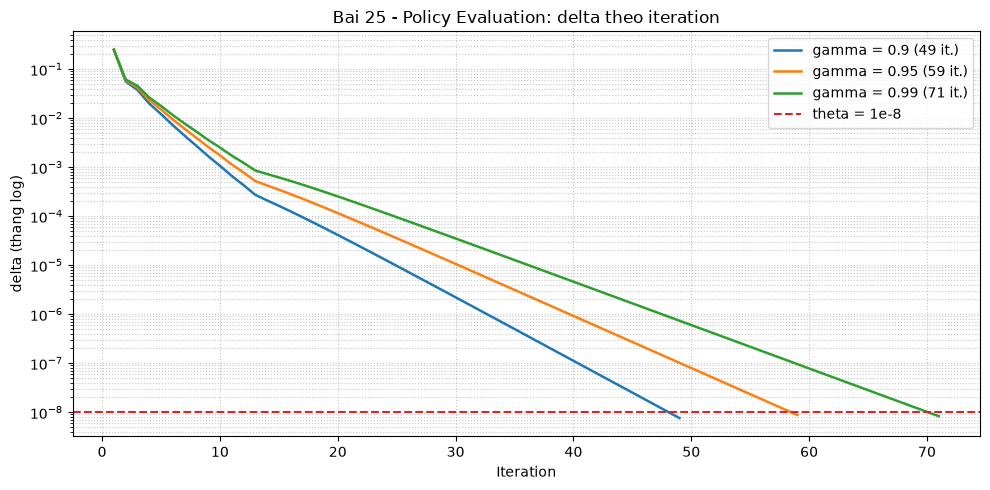

In [14]:
%matplotlib inline
# Bai 25 - theo doi hoi tu cua Policy Evaluation
deltas_by_gamma = {}
for g in [0.90, 0.95, 0.99]:
    _, n_it, deltas = U.policy_evaluation(env, random_policy, gamma=g,
                                          theta=1e-8, track_deltas=True)
    deltas_by_gamma[g] = deltas
    print(f"gamma = {g}: {n_it} iteration")

figure, axes = plt.subplots(figsize=(10, 5))
for g, deltas in deltas_by_gamma.items():
    axes.plot(range(1, len(deltas) + 1), deltas, linewidth=1.8,
              label=f"gamma = {g} ({len(deltas)} it.)")
axes.axhline(1e-8, color="#d62728", linestyle="--", label="theta = 1e-8")
axes.set_yscale("log")
axes.set_title("Bai 25 - Policy Evaluation: delta theo iteration")
axes.set_xlabel("Iteration")
axes.set_ylabel("delta (thang log)")
axes.grid(True, which="both", linestyle=":", alpha=0.7)
axes.legend()
figure.tight_layout()
plt.show()

**Nhận xét.** `delta` giảm theo cấp số nhân (đường thẳng trên trục log), hệ số
giảm xấp xỉ `gamma`. `gamma` càng gần 1 thì hội tụ càng chậm vì thông tin về
reward ở Goal phải lan truyền ngược xa hơn trước khi value ổn định. Đúng như
quan sát ở Bài 23: sau sweep đầu tiên chỉ state 14 (cạnh Goal) có giá trị khác 0,
mỗi sweep tiếp theo giá trị lan thêm một ô.

---
## PHẦN F — Policy Improvement và Policy Iteration (Bài 26–30)

In [15]:
# Bai 26-27 - greedy policy tu V va hien thi dang luoi
greedy_policy = U.greedy_policy_from_value(env, V_random, gamma)
print("Greedy policy tu V cua random policy:", greedy_policy)
U.print_policy_grid(env, greedy_policy)
print()
print("Bang ky hieu:", U.ACTION_SYMBOLS)

Greedy policy tu V cua random policy: [0 3 0 3 0 0 0 0 3 1 0 0 0 2 1 0]
  ← ↑ ← ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G

Bang ky hieu: {0: '←', 1: '↓', 2: '→', 3: '↑'}


In [16]:
# Bai 28 - mot buoc Policy Improvement va dem so state doi action
from bai28 import improvement_step

policy = np.zeros(n_states, dtype=np.int64)     # policy ban dau: luon di LEFT
for step in range(1, 11):
    old_policy = policy.copy()
    policy, V_step, n_eval_step, changed = improvement_step(env, policy, gamma)
    print(f"Buoc {step}: eval_sweeps={n_eval_step:4d}, so state doi action = {len(changed)}")
    if len(changed) == 0:
        print(f"=> Policy on dinh sau {step} buoc.")
        break

Buoc 1: eval_sweeps=   1, so state doi action = 1
Buoc 2: eval_sweeps=  33, so state doi action = 6
Buoc 3: eval_sweeps= 163, so state doi action = 4
Buoc 4: eval_sweeps= 173, so state doi action = 2
Buoc 5: eval_sweeps= 245, so state doi action = 2
Buoc 6: eval_sweeps= 370, so state doi action = 1
Buoc 7: eval_sweeps= 441, so state doi action = 0
=> Policy on dinh sau 7 buoc.


Policy Iteration converged after 7 iterations.
Tong Bellman sweep: 1426

Optimal state values:
   0.5420  0.4988  0.4707  0.4569
   0.5585  0.0000  0.3583  0.0000
   0.5918  0.6431  0.6152  0.0000
   0.0000  0.7417  0.8628  0.0000

Optimal policy:
  ← ↑ ↑ ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G


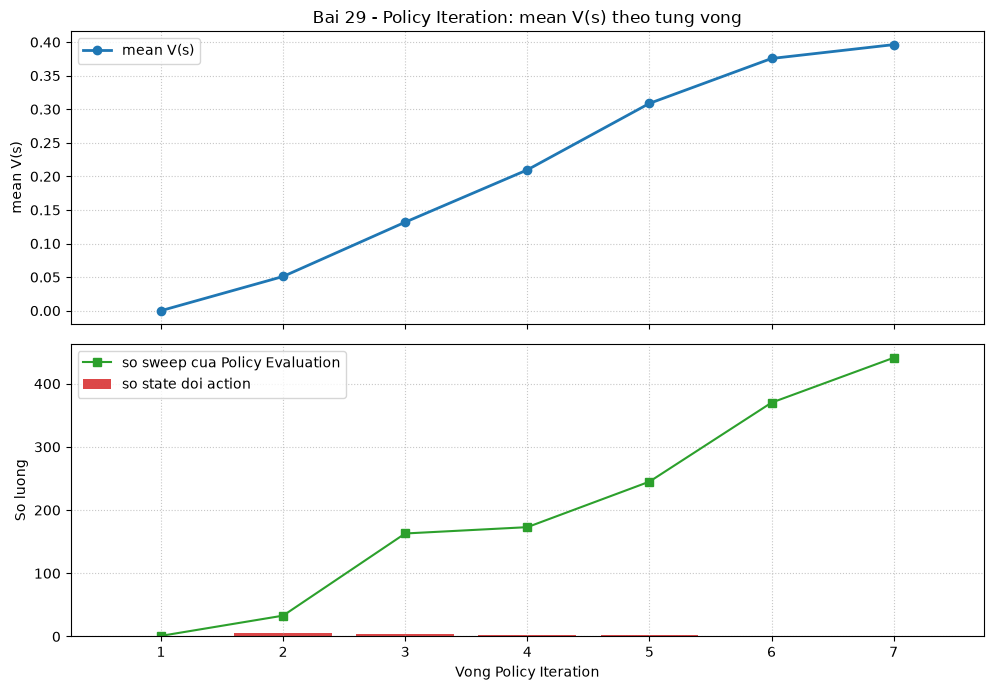

In [17]:
%matplotlib inline
# Bai 29-30 - Policy Iteration hoan chinh
policy_pi, V_pi, n_pi, history = U.policy_iteration(env, gamma=gamma, theta=1e-8,
                                                    track_history=True)
print(f"Policy Iteration converged after {n_pi} iterations.")
print(f"Tong Bellman sweep: {sum(history['eval_iterations'])}")
print()
print("Optimal state values:")
U.print_value_grid(env, V_pi)
print()
print("Optimal policy:")
U.print_policy_grid(env, policy_pi)

iterations = np.arange(1, n_pi + 1)
figure, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(iterations, history["mean_value"], marker="o", linewidth=2.0,
             color="#1f77b4", label="mean V(s)")
axes[0].set_title("Bai 29 - Policy Iteration: mean V(s) theo tung vong")
axes[0].set_ylabel("mean V(s)")
axes[0].grid(True, linestyle=":", alpha=0.7)
axes[0].legend()
axes[1].bar(iterations, history["n_changed"], color="#d62728", alpha=0.85,
            label="so state doi action")
axes[1].plot(iterations, history["eval_iterations"], marker="s", color="#2ca02c",
             label="so sweep cua Policy Evaluation")
axes[1].set_xlabel("Vong Policy Iteration")
axes[1].set_ylabel("So luong")
axes[1].grid(True, linestyle=":", alpha=0.7)
axes[1].legend()
figure.tight_layout()
plt.show()

---
## PHẦN G — Value Iteration (Bài 31–33)

```text
V*(s) <- max_a sum_(s') p(s'|s,a) * [ r + gamma * V*(s') ]
```

Khác Policy Evaluation ở chỗ lấy `max` thay vì lấy trung bình theo policy.

Sau 5 sweep:
  Policy Evaluation: [0.012271 0.05607  0.109311 0.       0.       0.134044 0.398382]
  Value Iteration  : [0.043723 0.159927 0.23782  0.       0.       0.305864 0.60338 ]



Value Iteration hoi tu sau 438 iteration
Optimal state values:
   0.5420  0.4988  0.4707  0.4569
   0.5585  0.0000  0.3583  0.0000
   0.5918  0.6431  0.6152  0.0000
   0.0000  0.7417  0.8628  0.0000

Optimal policy:
  ← ↑ ↑ ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G

Kiem chung V*(s) = max_a Q*(s,a): True
gamma = 0.9: 112 iteration
gamma = 0.95: 184 iteration
gamma = 0.99: 438 iteration


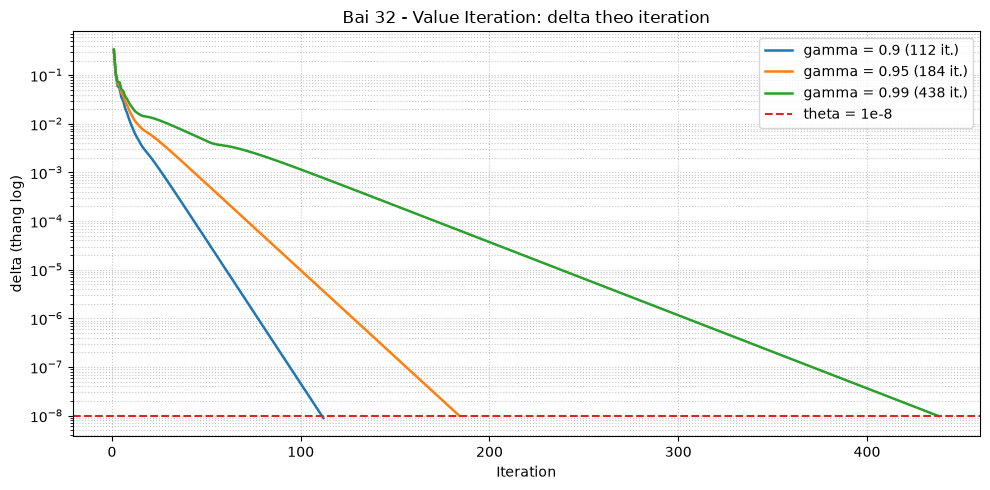

In [18]:
%matplotlib inline
# Bai 31 - mot sweep cua Value Iteration so voi mot sweep Policy Evaluation
V_pe = np.zeros(n_states)
V_vi_sweep = np.zeros(n_states)
for _ in range(5):
    V_pe = U.policy_evaluation_sweep(env, random_policy, V_pe, gamma)
    V_vi_sweep = U.value_iteration_sweep(env, V_vi_sweep, gamma)

print("Sau 5 sweep:")
print("  Policy Evaluation:", np.round(V_pe[8:15], 6))
print("  Value Iteration  :", np.round(V_vi_sweep[8:15], 6))
print()

# Bai 32-33 - Value Iteration hoan chinh va trich xuat optimal policy
V_vi, n_vi, deltas_vi = U.value_iteration(env, gamma=gamma, theta=1e-8)
optimal_policy = U.greedy_policy_from_value(env, V_vi, gamma)

print(f"Value Iteration hoi tu sau {n_vi} iteration")
print("Optimal state values:")
U.print_value_grid(env, V_vi)
print()
print("Optimal policy:")
U.print_policy_grid(env, optimal_policy)
print()
print("Kiem chung V*(s) = max_a Q*(s,a):",
      bool(np.allclose(V_vi, [np.max(U.action_values(env, V_vi, s, gamma))
                              for s in range(n_states)], atol=1e-6)))

deltas_by_gamma_vi = {}
for g in [0.90, 0.95, 0.99]:
    _, n_g, deltas_g = U.value_iteration(env, gamma=g, theta=1e-8)
    deltas_by_gamma_vi[g] = deltas_g
    print(f"gamma = {g}: {n_g} iteration")

figure, axes = plt.subplots(figsize=(10, 5))
for g, deltas in deltas_by_gamma_vi.items():
    axes.plot(range(1, len(deltas) + 1), deltas, linewidth=1.8,
              label=f"gamma = {g} ({len(deltas)} it.)")
axes.axhline(1e-8, color="#d62728", linestyle="--", label="theta = 1e-8")
axes.set_yscale("log")
axes.set_title("Bai 32 - Value Iteration: delta theo iteration")
axes.set_xlabel("Iteration")
axes.set_ylabel("delta (thang log)")
axes.grid(True, which="both", linestyle=":", alpha=0.7)
axes.legend()
figure.tight_layout()
plt.show()

**Nhận xét (Bài 33).** Policy tối ưu **không đi đường ngắn nhất**. Ở state 0 nó
chọn `LEFT` — đâm vào tường. Đó lại là lựa chọn an toàn nhất: hai hướng trượt
vuông góc với `LEFT` là `UP` (tường, đứng yên) và `DOWN` (state 4), nên agent
**không thể** rơi vào hố ở state 5. Đây là điều rất phản trực giác nếu chỉ nhìn
bản đồ, và là bằng chứng rằng policy được thuật toán sinh ra chứ không phải do
người viết đoán.

---
## PHẦN H — Đánh giá và so sánh thuật toán (Bài 34–36)

In [19]:
# Bai 34 - danh gia bang simulation, action = policy[state]
from bai34 import random_deterministic_policy

policies = {
    "Random": random_deterministic_policy(n_states, n_actions, seed=0),
    "Value Iteration": optimal_policy,
    "Policy Iteration": policy_pi,
}

print("Policy           | Success | Success rate | Mean reward | Mean len | Min | Max")
print("-----------------+---------+--------------+-------------+----------+-----+-----")
evaluations = {}
for name, pol in policies.items():
    result = U.evaluate_policy_by_simulation(env, pol, n_episodes=1000, seed=42)
    evaluations[name] = result
    print(f"{name:<17s}| {result['success']:^8d}| {result['success_rate']:^13.4f}| "
          f"{result['mean_reward']:^12.4f}| {result['mean_length']:^9.2f}| "
          f"{result['min_length']:^4d}| {result['max_length']:^4d}")

print()
print(f"V*(state 0) = {V_vi[0]:.4f} nhung success rate = "
      f"{evaluations['Value Iteration']['success_rate']:.4f}")
print("Hai so nay khac nhau vi V* la return CO CHIET KHAU (gamma = 0.99),")
print("con success rate la ty le thang khong chiet khau.")

Policy           | Success | Success rate | Mean reward | Mean len | Min | Max
-----------------+---------+--------------+-------------+----------+-----+-----
Random           |    27   |    0.0270    |    0.0270   |   7.29   |  2  |  35 


Value Iteration  |   724   |    0.7240    |    0.7240   |   44.03  |  6  | 100 


Policy Iteration |   724   |    0.7240    |    0.7240   |   44.03  |  6  | 100 

V*(state 0) = 0.5420 nhung success rate = 0.7240
Hai so nay khac nhau vi V* la return CO CHIET KHAU (gamma = 0.99),
con success rate la ty le thang khong chiet khau.


| Thuat toan       | Vong lap | Bellman sweep | Thoi gian (ms) | Success rate |
|------------------|---------:|--------------:|---------------:|-------------:|
| Value Iteration  |       438|            438|           51.35|        0.7240|
| Policy Iteration |         7|           1426|          181.23|        0.7240|

Hai policy giong nhau: True
Sai lech V lon nhat  : 1.30e-09


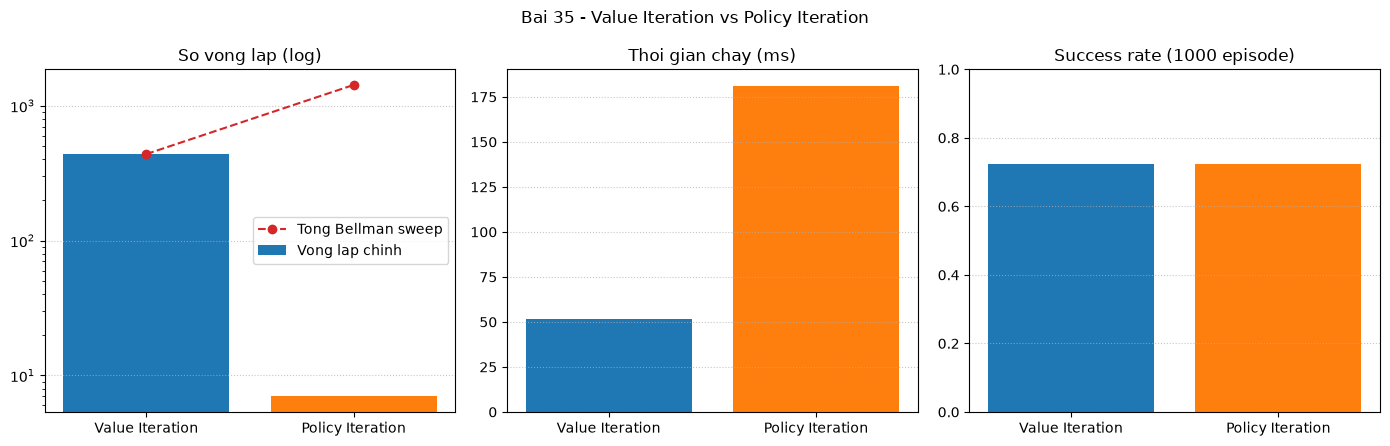

In [20]:
%matplotlib inline
# Bai 35 - so sanh Value Iteration va Policy Iteration
from time import perf_counter

start = perf_counter()
V_a, n_a, _ = U.value_iteration(env, gamma=gamma, theta=1e-8)
policy_a = U.greedy_policy_from_value(env, V_a, gamma)
time_vi = perf_counter() - start

start = perf_counter()
policy_b, V_b, n_b, history_b = U.policy_iteration(env, gamma=gamma, theta=1e-8,
                                                   track_history=True)
time_pi = perf_counter() - start
sweeps_pi = int(sum(history_b["eval_iterations"]))

print("| Thuat toan       | Vong lap | Bellman sweep | Thoi gian (ms) | Success rate |")
print("|------------------|---------:|--------------:|---------------:|-------------:|")
print(f"| Value Iteration  | {n_a:>9d}| {n_a:>14d}| {time_vi * 1000:>15.2f}| "
      f"{evaluations['Value Iteration']['success_rate']:>13.4f}|")
print(f"| Policy Iteration | {n_b:>9d}| {sweeps_pi:>14d}| {time_pi * 1000:>15.2f}| "
      f"{evaluations['Policy Iteration']['success_rate']:>13.4f}|")
print()
print("Hai policy giong nhau:", bool(np.array_equal(policy_a, policy_b)))
print("Sai lech V lon nhat  :", f"{float(np.max(np.abs(V_a - V_b))):.2e}")

names = ["Value Iteration", "Policy Iteration"]
figure, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].bar(names, [n_a, n_b], color=["#1f77b4", "#ff7f0e"], label="Vong lap chinh")
axes[0].plot(names, [n_a, sweeps_pi], "o--", color="#d62728", label="Tong Bellman sweep")
axes[0].set_yscale("log")
axes[0].set_title("So vong lap (log)")
axes[0].grid(True, axis="y", linestyle=":", alpha=0.7)
axes[0].legend()
axes[1].bar(names, [time_vi * 1000, time_pi * 1000], color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("Thoi gian chay (ms)")
axes[1].grid(True, axis="y", linestyle=":", alpha=0.7)
axes[2].bar(names, [evaluations[n]["success_rate"] for n in names],
            color=["#1f77b4", "#ff7f0e"])
axes[2].set_ylim(0, 1.0)
axes[2].set_title("Success rate (1000 episode)")
axes[2].grid(True, axis="y", linestyle=":", alpha=0.7)
figure.suptitle("Bai 35 - Value Iteration vs Policy Iteration")
figure.tight_layout()
plt.show()

env.close()

**Nhận xét Bài 35 (≥ 8 dòng).**

1. Hai thuật toán cho ra **cùng một optimal policy** và cùng `V*` (sai lệch
   `~1e-09`, đúng mức của `theta`) — cả hai đều hội tụ về nghiệm duy nhất của
   Bellman optimality equation.
2. Success rate ~0.724 là **giới hạn của chính bài toán**, không phải lỗi thuật
   toán: môi trường trượt khiến ~27% episode kết thúc dưới hố dù chơi tối ưu.
3. Policy Iteration chỉ cần **7 vòng chính** so với 438 iteration của Value
   Iteration, vì mỗi vòng nó giải gần như chính xác `V_pi`.
4. Nhưng tổng **Bellman sweep** của Policy Iteration là ~1 426, nhiều gấp hơn
   3 lần so với 438 của Value Iteration.
5. Vì thế Value Iteration chạy **nhanh hơn ~3 lần** — số vòng lặp chính ít không
   có nghĩa là rẻ hơn, chi phí thật nằm ở tổng số Bellman backup.
6. Policy Iteration có lợi thế khi không gian action lớn, hoặc khi Policy
   Evaluation giải được bằng hệ phương trình tuyến tính thay vì lặp.
7. Value Iteration đơn giản hơn về cài đặt: chỉ một vòng lặp duy nhất.
8. Cả hai đều **model-based**: bắt buộc phải truy cập `env.unwrapped.P`.
9. `gamma` càng gần 1 thì cả hai đều cần nhiều sweep hơn (112 → 184 → 438 khi
   gamma đi từ 0.90 → 0.95 → 0.99).

### Bài 36. Mini-project — Dynamic Programming Solver

Chương trình đầy đủ nằm ở `src/bai36.py`, chạy cả `is_slippery=False` và
`is_slippery=True`, có tham số `gamma`, `theta`, `max_iterations`.

In [21]:
bai36.main()

FrozenLake-v1 4x4, is_slippery=False, gamma=0.99, theta=1e-08
16 state, 4 action
Model co 64 transition tren 64 cap (state, action)

--- Value Iteration ---
  So vong lap chinh : 7
  Tong Bellman sweep: 7
  Thoi gian         : 0.85 ms
  V*(state 0)       : 0.950990
  Value table:
   0.9510  0.9606  0.9703  0.9606
   0.9606  0.0000  0.9801  0.0000
   0.9703  0.9801  0.9900  0.0000
   0.0000  0.9900  1.0000  0.0000
  Optimal policy:
  ↓ → ↓ ←
  ↓ H ↓ H
  → ↓ ↓ H
  H → → G
  Success rate      : 1.0000 (1000/1000 episode)
  Mean reward       : 1.0000
  Episode length    : mean 6.00, min 6, max 6

--- Policy Iteration ---
  So vong lap chinh : 7
  Tong Bellman sweep: 29
  Thoi gian         : 3.15 ms
  V*(state 0)       : 0.950990
  Value table:
   0.9510  0.9606  0.9703  0.9606
   0.9606  0.0000  0.9801  0.0000
   0.9703  0.9801  0.9900  0.0000
   0.0000  0.9900  1.0000  0.0000
  Optimal policy:
  ↓ → ↓ ←
  ↓ H ↓ H
  → ↓ ↓ H
  H → → G
  Success rate      : 1.0000 (1000/1000 episode)
  Mean 

--- Value Iteration ---
  So vong lap chinh : 438
  Tong Bellman sweep: 438
  Thoi gian         : 49.88 ms
  V*(state 0)       : 0.542026
  Value table:
   0.5420  0.4988  0.4707  0.4569
   0.5585  0.0000  0.3583  0.0000
   0.5918  0.6431  0.6152  0.0000
   0.0000  0.7417  0.8628  0.0000
  Optimal policy:
  ← ↑ ↑ ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G
  Success rate      : 0.7240 (724/1000 episode)
  Mean reward       : 0.7240
  Episode length    : mean 44.03, min 6, max 100



--- Policy Iteration ---
  So vong lap chinh : 7
  Tong Bellman sweep: 1426
  Thoi gian         : 153.47 ms
  V*(state 0)       : 0.542026
  Value table:
   0.5420  0.4988  0.4707  0.4569
   0.5585  0.0000  0.3583  0.0000
   0.5918  0.6431  0.6152  0.0000
   0.0000  0.7417  0.8628  0.0000
  Optimal policy:
  ← ↑ ↑ ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G
  Success rate      : 0.7240 (724/1000 episode)
  Mean reward       : 0.7240
  Episode length    : mean 44.03, min 6, max 100

So sanh hai thuat toan:
  Policy giong nhau : True
  Sai lech V lon nhat: 1.30e-09
  Thoi gian VI / PI  : 49.88 ms / 153.47 ms



BANG TONG HOP
| Cau hinh          | Thuat toan       | Vong lap | Sweep | ms     | Success |
|-------------------|------------------|---------:|------:|-------:|--------:|
| is_slippery=False | Value Iteration  |         7|      7|    0.85|    1.000|
| is_slippery=False | Policy Iteration |         7|     29|    3.15|    1.000|
| is_slippery=True  | Value Iteration  |       438|    438|   49.88|    0.724|
| is_slippery=True  | Policy Iteration |         7|   1426|  153.47|    0.724|

Convergence data saved to: D:\new_code\Lab02\data\value_iteration_deltas.csv
Figure saved to          : D:\new_code\Lab02\figures\mini_project_convergence.png

KET LUAN
------------------------------------------------------------------------
1. is_slippery=False: success rate 1.000 - moi truong tat dinh nen DP tim duoc duong di chac chan toi Goal.
2. is_slippery=True : success rate 0.724 - day la
   gioi han cua chinh bai toan, khong phai loi thuat toan.
3. Policy toi uu o che do tron di sat tuong de khi t

---
## Mục 12.4 — Xử lý terminal transition

Đề yêu cầu giải thích cách xử lý biến `terminated` trong transition model.

Trong `q_from_v()` (file `src/mdp_utils.py`):

```python
for probability, next_state, reward, terminated in transition_model[state][action]:
    future_value = 0.0 if terminated else gamma * V[next_state]
    q_value += probability * (reward + future_value)
```

**Vì sao phải làm vậy?** Một trạng thái kết thúc (hố hoặc Goal) không còn tương
lai: theo định nghĩa `V(terminal) = 0`. Nếu transition có `terminated=True` mà
ta vẫn bootstrap `gamma * V[next_state]` thì:

- giá trị của ô Goal sẽ được cộng ngược trở lại vào chính nó qua các vòng lặp,
- `V` của các ô lân cận bị thổi phồng và policy có thể sai.

Với FrozenLake, `P[terminal][a] = [(1.0, terminal, 0, True)]` — trạng thái kết
thúc tự lặp lại chính nó với reward 0. Nếu **không** kiểm tra `terminated` thì
`V[terminal] = gamma * V[terminal]` vẫn cho nghiệm 0 khi `gamma < 1`, nên kết
quả *tình cờ* vẫn đúng. Nhưng cách viết đó sai về mặt nguyên tắc và sẽ hỏng ngay
khi `gamma = 1` hoặc khi môi trường có reward khác 0 ở trạng thái kết thúc. Vì
vậy code ở đây luôn kiểm tra `terminated` một cách tường minh.

In [22]:
# Chung minh bang so: so sanh hai cach cai dat q_from_v
env_check = U.create_environment(map_name="4x4", is_slippery=True)


def q_from_v_khong_kiem_tra_terminated(env, V, state, action, gamma):
    """Ban SAI: bootstrap ca o transition co terminated=True."""
    q_value = 0.0
    for probability, next_state, reward, terminated in U.get_transition_model(env)[state][action]:
        q_value += probability * (reward + gamma * V[next_state])
    return q_value


V_test = np.ones(16)     # gia su moi state deu co gia tri 1
for state, action in [(14, 2), (5, 0), (15, 0)]:
    correct = U.q_from_v(env_check, V_test, state, action, 0.99)
    wrong = q_from_v_khong_kiem_tra_terminated(env_check, V_test, state, action, 0.99)
    print(f"state={state:2d}, action={action}: dung = {correct:.6f}, "
          f"bo qua terminated = {wrong:.6f}, lech = {wrong - correct:+.6f}")

env_check.close()
print()
print("Voi V khac 0, hai cach cho ket qua KHAC NHAU o moi transition ket thuc.")

state=14, action=2: dung = 0.993333, bo qua terminated = 1.323333, lech = +0.330000
state= 5, action=0: dung = 0.000000, bo qua terminated = 0.990000, lech = +0.990000
state=15, action=0: dung = 0.000000, bo qua terminated = 0.990000, lech = +0.990000

Voi V khac 0, hai cach cho ket qua KHAC NHAU o moi transition ket thuc.


---
## Mục 13 — Trả lời 25 câu hỏi

**1. Markov property là gì?**
Tương lai chỉ phụ thuộc trạng thái hiện tại, không phụ thuộc cách đi tới đó:
`P(S_{t+1} | S_t, A_t) = P(S_{t+1} | S_0..S_t, A_0..A_t)`. Trạng thái hiện tại
đã "tóm gọn" toàn bộ lịch sử cần thiết.

**2. Markov chain khác MDP như thế nào?**
Markov chain chỉ có state và xác suất chuyển — không có ai ra quyết định. MDP
thêm **action** (agent chọn) và **reward**, nên transition trở thành
`p(s'|s,a)` chứ không phải `p(s'|s)`. Nói cách khác: MDP + một policy cố định
= một Markov chain.

**3. Transition probability là gì?**
`p(s'|s,a)` — xác suất môi trường chuyển sang `s'` khi agent thực hiện `a` tại
`s`. Trong Gymnasium nó nằm ở `env.unwrapped.P[s][a]` dưới dạng list các tuple
`(probability, next_state, reward, terminated)`.

**4. Vì sao tổng transition probability của một `(state, action)` phải bằng 1?**
Vì đó là một phân phối xác suất đầy đủ trên tập trạng thái kế tiếp: sau khi
thực hiện action, môi trường **chắc chắn** rơi vào đúng một trạng thái nào đó.
Tổng khác 1 nghĩa là model bị thiếu/thừa nhánh, và Bellman backup sẽ tính sai
kỳ vọng.

**5. Return khác immediate reward như thế nào?**
Immediate reward `R_{t+1}` là phần thưởng của **một bước**. Return `G_t` là
tổng (có chiết khấu) của **toàn bộ** reward còn lại của episode. RL tối đa hóa
return, không phải reward từng bước — đó là lý do agent chấp nhận reward 0 ở
nhiều bước để tới được Goal.

**6. Discount factor có vai trò gì?**
Ba vai trò: (a) cân bằng giữa phần thưởng gần và xa; (b) đảm bảo return hữu hạn
với episode dài/vô hạn; (c) mô hình hoá sự "không chắc chắn" về tương lai. Nó
cũng ảnh hưởng trực tiếp tới tốc độ hội tụ của DP.

**7. Khi `gamma = 0`, agent quan tâm điều gì?**
Chỉ quan tâm reward ngay bước kế tiếp: `G_t = R_{t+1}`. Agent hoàn toàn thiển
cận. Trên FrozenLake điều này khiến mọi state trừ ô cạnh Goal đều có giá trị 0
và không thể học được đường đi.

**8. Khi `gamma` gần 1, reward xa trong tương lai ảnh hưởng thế nào?**
Ảnh hưởng gần như nguyên vẹn: với `gamma = 0.99`, reward sau 4 bước còn giữ
`0.99^4 = 96%` giá trị. Đổi lại, thông tin phải lan truyền xa hơn nên DP cần
nhiều iteration hơn (438 với gamma=0.99 so với 112 với gamma=0.90).

**9. Policy là gì?**
Quy tắc ánh xạ state sang action, `pi(a|s)`. Nó là thứ duy nhất agent thực sự
"sở hữu"; toàn bộ mục tiêu của RL là tìm policy tối ưu.

**10. Deterministic policy khác stochastic policy thế nào?**
Deterministic: mỗi state gán đúng một action, biểu diễn bằng mảng `policy[s] = a`.
Stochastic: mỗi state là một phân phối xác suất trên action, ma trận
`(n_states, n_actions)` với tổng mỗi hàng bằng 1. Deterministic là trường hợp
đặc biệt (one-hot) của stochastic.

**11. `V(s)` biểu diễn điều gì?**
Kỳ vọng return khi **bắt đầu từ state `s`** và đi theo policy `pi`:
`V_pi(s) = E_pi[G_t | S_t = s]`. Nó trả lời "đứng ở đây thì tốt cỡ nào".

**12. `Q(s,a)` biểu diễn điều gì?**
Kỳ vọng return khi ở `s`, **thực hiện action `a`**, rồi mới đi theo `pi`:
`Q_pi(s,a) = E_pi[G_t | S_t = s, A_t = a]`. Nó trả lời "làm hành động này ở đây
thì tốt cỡ nào" — và chính vì thế mới cải thiện được policy bằng `argmax_a Q`.

**13. Bellman equation có tính đệ quy ở điểm nào?**
Giá trị của một state được định nghĩa qua giá trị của các state kế tiếp:
`V(s) = E[r + gamma * V(s')]`. `V` xuất hiện ở cả hai vế — đó là một hệ phương
trình điểm bất động, và DP giải nó bằng cách lặp.

**14. Bellman expectation khác Bellman optimality thế nào?**
Expectation lấy **trung bình theo policy**: `V_pi(s) = sum_a pi(a|s) * Q_pi(s,a)`
— dùng để *đánh giá* một policy cho trước. Optimality lấy **max theo action**:
`V*(s) = max_a Q*(s,a)` — dùng để tìm policy *tốt nhất*. Về code, khác đúng một
chỗ: `np.dot(policy[s], q_values)` so với `np.max(q_values)`.

**15. Dynamic Programming cần biết thông tin gì về môi trường?**
Cần **toàn bộ transition model**: `p(s'|s,a)` và reward tương ứng, tức
`env.unwrapped.P`. DP là thuật toán *model-based* — nó không cần tương tác với
môi trường lần nào, chỉ cần đọc model.

**16. Policy Evaluation dùng để làm gì?**
Tính `V_pi` cho một policy **cho trước** (chưa cải thiện gì). Nó trả lời "policy
này tốt cỡ nào ở mỗi state". Đây là bước "đo lường" của DP.

**17. Policy Improvement dùng để làm gì?**
Từ `V_pi` sinh ra policy mới tốt hơn (hoặc bằng) bằng cách chọn tham lam
`argmax_a Q_pi(s,a)`. Định lý policy improvement đảm bảo policy mới không bao
giờ tệ hơn. Đây là bước "cải thiện".

**18. Policy Iteration hoạt động như thế nào?**
Lặp xen kẽ hai bước trên: Evaluation → Improvement → kiểm tra `policy_stable` →
lặp lại nếu policy còn đổi. Vì số policy deterministic là hữu hạn và mỗi vòng
đều cải thiện, thuật toán chắc chắn dừng. Trong bài này: 7 vòng.

**19. Value Iteration hoạt động như thế nào?**
Bỏ hẳn bước evaluation đầy đủ, mỗi sweep chỉ áp dụng một lần Bellman
**optimality** backup `V(s) <- max_a Q(s,a)`, lặp tới khi `delta < theta`. Sau
đó trích policy bằng một lần greedy. Trong bài này: 438 iteration.

**20. Value Iteration khác Policy Iteration ở điểm nào?**
Value Iteration = Policy Iteration với Policy Evaluation bị cắt còn **đúng một
sweep** và dùng `max` thay vì trung bình. Hệ quả: Policy Iteration ít vòng
chính hơn (7 so với 438) nhưng tổng Bellman sweep nhiều hơn (1 426 so với 438),
nên thực tế lại chậm hơn khoảng 3 lần trên bản đồ 4x4.

**21. Vì sao `FrozenLake-v1` thích hợp để minh họa Dynamic Programming?**
Vì nó có đủ ba điều kiện: (a) không gian state/action nhỏ và rời rạc (16x4) nên
duyệt hết được; (b) Gymnasium công khai transition model qua `env.unwrapped.P`;
(c) có phiên bản tất định và phiên bản ngẫu nhiên để so sánh trực tiếp ảnh
hưởng của transition probability.

**22. `is_slippery=True` làm model thay đổi như thế nào?**
Mỗi `(state, action)` từ 1 transition thành **3 transition**, mỗi cái xác suất
1/3: đi đúng hướng, hoặc trượt sang một trong hai hướng vuông góc. Hệ quả:
policy tối ưu đổi hẳn — nó đi sát tường để khi trượt vẫn không rơi vào hố — và
success rate tối đa tụt từ 1.00 xuống 0.72.

**23. `theta` ảnh hưởng thế nào đến số iteration?**
`theta` là ngưỡng dừng nên nó đánh đổi độ chính xác lấy số vòng lặp. Đo được
với Policy Evaluation (gamma=0.99): `1e-2` cho 7 iteration nhưng `V(0)` sai tới
87%; `1e-4` cho 25; `1e-6` cho 48; `1e-8` cho 71; `1e-10` cho 93 iteration. Vì
`delta` giảm theo cấp số nhân nên số iteration tăng **tuyến tính** theo số chữ
số chính xác.

**24. Vì sao cần đánh giá optimal policy bằng simulation?**
Hai lý do. (a) **Kiểm chứng độc lập**: `V*` là con số do chính thuật toán sinh
ra; chạy policy thật trên môi trường xác nhận nó hoạt động, bắt được lỗi cài
đặt. (b) **Đo đại lượng khác**: `V*(0) = 0.542` là return có chiết khấu, còn
success rate `0.724` và mean episode length `44.03` là những thứ `V*` không nói
trực tiếp.

**25. Nếu không biết transition model, DP có áp dụng trực tiếp được không?**
**Không.** Cả hai thuật toán đều cần `sum_{s'} p(s'|s,a) * [...]`, tức phải
biết trước xác suất và reward của mọi nhánh. Không có model thì có hai hướng:
(a) *học* model từ dữ liệu rồi chạy DP (model-based RL); hoặc (b) bỏ qua model
và ước lượng giá trị trực tiếp từ kinh nghiệm — Monte Carlo, Temporal-Difference
Learning, SARSA, Q-Learning — đó chính là nội dung các Lab tiếp theo.

---
## Kết luận chung

- Chuỗi logic của Lab02: **model → Bellman equation → value function →
  policy improvement → optimal policy**. Mọi bài đều là một mắt xích trong chuỗi này.
- Value Iteration và Policy Iteration cho **cùng một nghiệm**; khác biệt duy
  nhất là chi phí tính toán, và số vòng lặp chính không phải thước đo đúng —
  phải đếm tổng số Bellman backup.
- Policy tối ưu trên bản đồ trượt **đi sát tường**, không đi đường ngắn nhất.
  Đây là kết quả mà trực giác con người rất dễ đoán sai, và là minh chứng rằng
  policy do thuật toán sinh ra chứ không phải hard-code.
- Success rate 0.724 là **giới hạn của bài toán**, không phải giới hạn của
  thuật toán: với `is_slippery=False` thì DP đạt 100%.
- Điểm yếu cốt lõi của DP là **cần biết transition model**. Đó chính là lý do
  các Lab sau chuyển sang Monte Carlo và Temporal-Difference Learning, nơi
  agent học trực tiếp từ episode mà không cần `env.unwrapped.P`.